## Installations

In [2]:
# !pip install pandas scikit-learn --quiet
!pip install tensorflow --quiet
!pip install gensim --quiet
!pip install --upgrade transformers[sentencepiece] --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 35.0 MB/s eta 0:00:00


## Imports

In [3]:
import pandas as pd
import numpy as np
import random
import nltk
import tensorflow as tf
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from scipy.stats import chi2
import re
import torch.nn.functional as F
from tqdm import tqdm
import math
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

In [1]:
drive.mount('/content/drive')

Mounted at /content/drive


## Constants

In [4]:
# Config
CHECKPOINT = "distilbert-base-uncased"
MAX_LEN_CLAIM = 100
MAX_LEN_EVIDENCE = 300
BATCH_SIZE = 32
NUM_CLASSES = 2
HIDDEN_SIZE = 128
COMPOSE_HIDDEN = 256
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAINING_SET = '/content/train.csv'
VALIDATION_SET = '/content/dev.csv'

# MODE --------------- "Training" or "Inference"
MODE = "Training"

In [5]:
if MODE == "Training":
    VALIDATION_SET = '/content/dev.csv'
else:
    VALIDATION_SET = '/content/test.csv'

##Data Loading

In [6]:
# Load datasets

training = pd.read_csv(TRAINING_SET)
validation = pd.read_csv(VALIDATION_SET)

In [7]:
# Class
class ClaimEvidenceDataset(Dataset):
    def __init__(self, claims, evidences, labels, tokenizer):
        self.claims = claims
        self.evidences = evidences
        self.labels = labels
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.claims)

    def __getitem__(self, idx):
        claim = self.claims[idx]
        evidence = self.evidences[idx]
        label = self.labels[idx]

        # Separate encodings (ESIM)
        claim_enc = self.tokenizer(
            claim,
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN_CLAIM,
            return_tensors='pt'
        )

        evidence_enc = self.tokenizer(
            evidence,
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN_EVIDENCE,
            return_tensors='pt'
        )

        # Pair encoding (BERT cross-attention)
        pair_enc = self.tokenizer(
            claim,
            evidence,
            padding='max_length',
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )

        return {
            'claim_input_ids': claim_enc['input_ids'].squeeze(0),
            'claim_attention_mask': claim_enc['attention_mask'].squeeze(0),

            'evidence_input_ids': evidence_enc['input_ids'].squeeze(0),
            'evidence_attention_mask': evidence_enc['attention_mask'].squeeze(0),

            'pair_input_ids': pair_enc['input_ids'].squeeze(0),
            'pair_attention_mask': pair_enc['attention_mask'].squeeze(0),

            'label': torch.tensor(label, dtype=torch.long)
        }

##DataLoader

In [8]:
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

train_dataset = ClaimEvidenceDataset(training['Claim'].tolist(),
                                     training['Evidence'].tolist(),
                                     training['label'].tolist(),
                                     tokenizer)

# Handle validation set for inference mode
if MODE == "Training":
    val_labels = validation['label'].tolist()
else:
    # In Inference mode, test.csv doesn't have label column.
    # Provide dummy labels as placeholders for the dataset constructor.
    val_labels = [0] * len(validation) # Create a list of zeros as dummy labels

val_dataset = ClaimEvidenceDataset(validation['Claim'].tolist(),
                                   validation['Evidence'].tolist(),
                                   val_labels,
                                   tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

##ESIM Model

In [9]:
class ESIMWithBERT(nn.Module):
    def __init__(self, checkpoint=CHECKPOINT, hidden_size=HIDDEN_SIZE, compose_hidden=COMPOSE_HIDDEN, num_classes=NUM_CLASSES):
        super().__init__()

        # BERT
        self.bert = AutoModel.from_pretrained(checkpoint)

        # ESIM layers
        self.encode_bilstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

        self.compose_bilstm = nn.LSTM(
            input_size=8 * hidden_size,
            hidden_size=compose_hidden,
            batch_first=True,
            bidirectional=True
        )

        # Classifier
        self.fc1 = nn.Linear(8 * compose_hidden + self.bert.config.hidden_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc_out = nn.Linear(128, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    # Masked pooling functions
    def masked_mean(self, tensor, mask):
        mask = mask.unsqueeze(-1).float()
        return (tensor * mask).sum(dim=1) / mask.sum(dim=1)

    def masked_max(self, tensor, mask):
        mask = mask.unsqueeze(-1)
        tensor = tensor.masked_fill(mask == 0, -1e9)
        return tensor.max(dim=1)[0]

    def forward(self, claim_ids, claim_mask, evidence_ids, evidence_mask, pair_ids, pair_mask):

        # BERT embeddings (lower layer)
        claim_outputs = self.bert(
            input_ids=claim_ids,
            attention_mask=claim_mask,
            output_hidden_states=True
        )
        evidence_outputs = self.bert(
            input_ids=evidence_ids,
            attention_mask=evidence_mask,
            output_hidden_states=True
        )

        claim_emb = claim_outputs.hidden_states[-4]
        evidence_emb = evidence_outputs.hidden_states[-4]

        # Cross encoded BERT signal
        pair_inputs = self.bert(
            input_ids=pair_ids,
            attention_mask=pair_mask
        )

        pair_cls = pair_inputs.last_hidden_state[:, 0]

        # Encoding BiLSTM
        claim_encoded, _ = self.encode_bilstm(claim_emb)
        evidence_encoded, _ = self.encode_bilstm(evidence_emb)

        # Attention (masking)
        attention = torch.matmul(
            claim_encoded,
            evidence_encoded.transpose(1, 2)
        )

        # Claim → Evidence
        evidence_mask_exp = evidence_mask.unsqueeze(1)
        attention_c2e = attention.masked_fill(evidence_mask_exp == 0, -1e9)
        claim_att = torch.softmax(attention_c2e, dim=-1)

        # Evidence → Claim
        attention_e2c = attention.transpose(1, 2)
        claim_mask_exp = claim_mask.unsqueeze(1)
        attention_e2c = attention_e2c.masked_fill(claim_mask_exp == 0, -1e9)
        evidence_att = torch.softmax(attention_e2c, dim=-1)

        # Alignments
        aligned_evidence = torch.matmul(claim_att, evidence_encoded)
        aligned_claim = torch.matmul(evidence_att, claim_encoded)

        # Enhanced representations
        claim_enh = torch.cat([
            claim_encoded,
            aligned_evidence,
            claim_encoded - aligned_evidence,
            claim_encoded * aligned_evidence
        ], dim=-1)

        evidence_enh = torch.cat([
            evidence_encoded,
            aligned_claim,
            evidence_encoded - aligned_claim,
            evidence_encoded * aligned_claim
        ], dim=-1)

        # Composition BiLSTM
        claim_comp, _ = self.compose_bilstm(claim_enh)
        evidence_comp, _ = self.compose_bilstm(evidence_enh)

        # Masked Pooling
        claim_avg = self.masked_mean(claim_comp, claim_mask)
        claim_max = self.masked_max(claim_comp, claim_mask)

        evidence_avg = self.masked_mean(evidence_comp, evidence_mask)
        evidence_max = self.masked_max(evidence_comp, evidence_mask)

        merged = torch.cat([
            claim_avg, claim_max,
            evidence_avg, evidence_max
        ], dim=-1)

        # BERT CLS residual
        merged = torch.cat([merged, pair_cls], dim=-1)

        # Classifier
        x = self.dropout(self.relu(self.fc1(merged)))
        x = self.dropout(self.relu(self.fc2(x)))

        logits = self.fc_out(x)
        return logits

##Training Loop

In [11]:
if MODE == "Training":
  best_val_f1 = 0

  model = ESIMWithBERT().to(DEVICE)
  optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

  EPOCHS = 4

  for epoch in range(EPOCHS):
      print(f"\nEpoch {epoch+1}/{EPOCHS}")

      # Training
      model.train()
      train_loss = 0
      train_acc = 0

      for batch in tqdm(train_loader, desc="Training", ncols=100):
          optimizer.zero_grad()

          # Move all inputs to device
          claim_ids = batch['claim_input_ids'].to(DEVICE)
          claim_mask = batch['claim_attention_mask'].to(DEVICE)
          evidence_ids = batch['evidence_input_ids'].to(DEVICE)
          evidence_mask = batch['evidence_attention_mask'].to(DEVICE)

          # Pair inputs
          pair_ids = batch['pair_input_ids'].to(DEVICE)
          pair_mask = batch['pair_attention_mask'].to(DEVICE)

          labels = batch['label'].to(DEVICE)

          # Forward pass
          logits = model(
              claim_ids, claim_mask,
              evidence_ids, evidence_mask,
              pair_ids, pair_mask  # pass pair inputs
          )

          loss = F.cross_entropy(logits, labels)
          loss.backward()
          optimizer.step()

          train_loss += loss.item() * claim_ids.size(0)
          train_acc += (logits.argmax(dim=1) == labels).sum().item()

      train_loss /= len(train_dataset)
      train_acc /= len(train_dataset)

      # Validation
      model.eval()
      val_loss = 0
      val_acc = 0

      all_preds = []
      all_labels = []

      with torch.no_grad():
          for batch in val_loader:
              claim_ids = batch['claim_input_ids'].to(DEVICE)
              claim_mask = batch['claim_attention_mask'].to(DEVICE)
              evidence_ids = batch['evidence_input_ids'].to(DEVICE)
              evidence_mask = batch['evidence_attention_mask'].to(DEVICE)

              pair_ids = batch['pair_input_ids'].to(DEVICE)
              pair_mask = batch['pair_attention_mask'].to(DEVICE)

              labels = batch['label'].to(DEVICE)

              logits = model(
                  claim_ids, claim_mask,
                  evidence_ids, evidence_mask,
                  pair_ids, pair_mask
              )

              loss = F.cross_entropy(logits, labels)

              val_loss += loss.item() * claim_ids.size(0)
              val_acc += (logits.argmax(dim=1) == labels).sum().item()

              preds = logits.argmax(dim=1)
              all_preds.extend(preds.cpu().numpy())
              all_labels.extend(labels.cpu().numpy())

      val_loss /= len(val_dataset)
      val_acc /= len(val_dataset)


      val_f1 = f1_score(all_labels, all_preds, average='weighted')

      print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

      if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pt")
        print("Saved best model")

  model.load_state_dict(torch.load("best_model.pt"))
  print(f"\n Best Validation F1: {best_val_f1:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Epoch 1/4


Training: 100%|███████████████████████████████████████████████████| 673/673 [26:28<00:00,  2.36s/it]


Train Loss: 0.3994, Train Acc: 0.8152 | Val Loss: 0.3206, Val Acc: 0.8527
Saved best model

Epoch 2/4


...

Train Loss: 0.2610, Train Acc: 0.8882 | Val Loss: 0.2970, Val Acc: 0.8670
Saved best model

Epoch 3/4


Training: 100%|███████████████████████████████████████████████████| 673/673 [26:23<00:00,  2.35s/it]


Train Loss: 0.1672, Train Acc: 0.9344 | Val Loss: 0.3598, Val Acc: 0.8652

Epoch 4/4


Training: 100%|███████████████████████████████████████████████████| 673/673 [26:23<00:00,  2.35s/it]


Train Loss: 0.0964, Train Acc: 0.9669 | Val Loss: 0.4424, Val Acc: 0.8640

 Best Validation F1: 0.8673


## Save Model

In [12]:
# Save the current best model weights to drive to remove re-training the model after session ends

if MODE == "Training":
  SAVE_PATH = "/content/drive/MyDrive/esim_bert_model.pt"

  torch.save(model.state_dict(), SAVE_PATH)

  print("Model saved to:", SAVE_PATH)

Model saved to: /content/drive/MyDrive/esim_bert_model.pt


In [10]:
# Load the best model saved on drive

drive.mount('/content/drive')

model = ESIMWithBERT().to(DEVICE)
model.load_state_dict(torch.load("/content/drive/MyDrive/esim_bert_model.pt", map_location=DEVICE))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

##Evaluation

In [11]:
# Evaluate model on the validation dataset

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        claim_ids = batch['claim_input_ids'].to(DEVICE)
        claim_mask = batch['claim_attention_mask'].to(DEVICE)
        evidence_ids = batch['evidence_input_ids'].to(DEVICE)
        evidence_mask = batch['evidence_attention_mask'].to(DEVICE)

        # Add pair inputs
        pair_ids = batch['pair_input_ids'].to(DEVICE)
        pair_mask = batch['pair_attention_mask'].to(DEVICE)

        labels = batch['label'].to(DEVICE)

        logits = model(claim_ids, claim_mask, evidence_ids, evidence_mask, pair_ids, pair_mask)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [12]:
# Save model predictions to text file

preds = all_preds
np.savetxt("nli_predictions.txt", preds, fmt="%d")

## Metrics

Accuracy: 0.8670

--- Macro Metrics ---
Macro Precision: 0.8331
Macro Recall:    0.8364
Macro F1:        0.8347

--- Weighted Metrics ---
Weighted Precision: 0.8677
Weighted Recall:    0.8670
Weighted F1:        0.8673
Matthews Corrcoef: 0.6695

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      4286
           1       0.76      0.77      0.76      1640

    accuracy                           0.87      5926
   macro avg       0.83      0.84      0.83      5926
weighted avg       0.87      0.87      0.87      5926



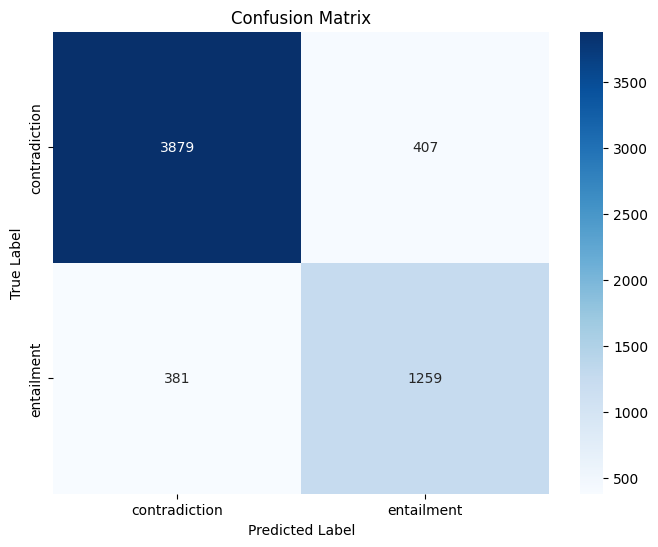

In [16]:
# Display metrics for the validation/dev dataset

if MODE == "Training":
  # Core metrics
  accuracy = accuracy_score(all_labels, all_preds)

  macro_precision = precision_score(all_labels, all_preds, average='macro')
  macro_recall = recall_score(all_labels, all_preds, average='macro')
  macro_f1 = f1_score(all_labels, all_preds, average='macro')

  weighted_precision = precision_score(all_labels, all_preds, average='weighted')
  weighted_recall = recall_score(all_labels, all_preds, average='weighted')
  weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

  mcc = matthews_corrcoef(all_labels, all_preds)

  # Print results
  print(f"Accuracy: {accuracy:.4f}")

  print("\n--- Macro Metrics ---")
  print(f"Macro Precision: {macro_precision:.4f}")
  print(f"Macro Recall:    {macro_recall:.4f}")
  print(f"Macro F1:        {macro_f1:.4f}")

  print("\n--- Weighted Metrics ---")
  print(f"Weighted Precision: {weighted_precision:.4f}")
  print(f"Weighted Recall:    {weighted_recall:.4f}")
  print(f"Weighted F1:        {weighted_f1:.4f}")
  print(f"Matthews Corrcoef: {mcc:.4f}")

  # Diagnostic report
  print("\nClassification Report:\n")
  print(classification_report(all_labels, all_preds))


  # Compute confusion matrix
  cm = confusion_matrix(all_labels, all_preds)

  cm_df = pd.DataFrame(cm, index=['contradiction', 'entailment'], columns=['contradiction', 'entailment'])

  # Plot confusion matrix
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title('Confusion Matrix')
  plt.show()

## McNamer Test between the 2 models proposed for ED

In [26]:
if MODE == "Training":
  # Load predictions

  # ESIM + DistilBERT hybrid model
  pred_A = np.loadtxt("nli_predictions.txt")

  # DEBERTa with Attention Mechanism
  pred_B = np.loadtxt("predictionsDEV2.csv", skiprows=1)

  # Load gold labels
  gold = np.array(all_labels) # Convert list to NumPy array

  # Convert to integers
  pred_A = pred_A.astype(int)
  pred_B = pred_B.astype(int)
  gold = gold.astype(int)

  # Check sizes
  print("Lengths:", len(pred_A), len(pred_B), len(gold))

  # Correct/incorrect masks
  a_correct = pred_A == gold
  b_correct = pred_B == gold

  # McNemar counts
  n01 = np.sum((a_correct == True) & (b_correct == False))
  n10 = np.sum((a_correct == False) & (b_correct == True))

  # McNemar test
  if (n01 + n10) > 0:
      chi2_stat = (abs(n01 - n10) - 1)**2 / (n01 + n10)
      p_value = 1 - chi2.cdf(chi2_stat, 1)
  else:
      chi2_stat = 0.0
      p_value = 1.0

  print("n01 (A correct, B wrong):", n01)
  print("n10 (A wrong, B correct):", n10)
  print("Chi-square:", chi2_stat)
  print("p-value:", p_value)

Lengths: 5926 5926 5926
n01 (A correct, B wrong): 296
n10 (A wrong, B correct): 386
Chi-square: 11.614369501466276
p-value: 0.0006544421974674641


## Error Analysis

In [14]:
# Look at 20 misclassed examples to analyse where the model struggles

misclassified_examples = []

for i in range(len(all_preds)):
    if all_preds[i] != all_labels[i]:
        misclassified_examples.append({
            'claim': validation['Claim'].iloc[i],
            'evidence': validation['Evidence'].iloc[i],
            'true_label': all_labels[i],
            'predicted_label': all_preds[i]
        })

print(f"Found {len(misclassified_examples)} misclassified examples.")

# Randomly pick up to 20 misclassified examples
num_to_show = min(20, len(misclassified_examples))
selected_misclassified = random.sample(misclassified_examples, num_to_show)

print(f"\nDisplaying {num_to_show} random misclassified examples:")
for i, example in enumerate(selected_misclassified):
    print(f"\n--- Example {i+1} ---")
    print(f"Claim: {example['claim']}")
    print(f"Evidence: {example['evidence']}")
    print(f"True Label: {example['true_label']}")
    print(f"Predicted Label: {example['predicted_label']}")

Found 788 misclassified examples.

Displaying 20 random misclassified examples:

--- Example 1 ---
Claim: We should not subsidize single parents
Evidence: Linked to the rising prevalence of single parenting is the increasing quality of health care, and there have been findings of positive developmental effects with modern childcare.
True Label: 0
Predicted Label: 1

--- Example 2 ---
Claim: We should fight global warming
Evidence: In an interview in Local Transport Today in 2006, Peiser argued that environmental concerns in general and concern about global warming in particular had reached a level of "near hysteria" and was "poisonous for rational policy making" [REF].
True Label: 1
Predicted Label: 0

--- Example 3 ---
Claim: We should cancel the speed limit
Evidence: Current estimates conclude that a speed limit would reduce Germany's overall CO2 emission by a mere fraction of a percent, and in terms of highway safety, German Autobahns are among the world's safest.
True Label: 0
Pred

In [17]:
# Display the split between class predictions

predictions_series = pd.Series(all_preds)
print("Predicted label distribution:")
display(predictions_series.value_counts().sort_index())

Predicted label distribution:


,count
0,4260
1,1666
